# SIRI-ET Compare
This Jupyter Notebook compares the data quality of DELFI SIRI-ET stream with the original communication logs of an ITCS of IVU. It requires two input files:
- `data/itcs.log` The communication logs of the IVU ITCS
- `data/siriet/*.xml` At least one recorded SIRI-ET dump of DELFI

## 1. Step: Extraction of ITCS Data
The ITCS log contains mixed text block logs and XML dumps of the VDV454-AUS data. The extraction block parses the XML contents and builds a dict in following structure:

```python
{
    'JourneyRef': [
        datetime(...),
        datetime(...),
        datetime(...),
        ...
    ]
}
```

This structure contains each journey and all timestamps, when data have been delivered for this journey.

In [6]:
from __future__ import annotations

from collections import defaultdict
from datetime import datetime
from typing import DefaultDict
from xml.etree import ElementTree as ET


# Result structure:
# {
#     "FahrtBezeichner": [datetime(...), datetime(...)]
# }
trip_timestamps: DefaultDict[str, list[datetime]] = defaultdict(list)


def process_xml(xml_text: str) -> None:
    """Extract timestamps and trip identifiers from a single XML block."""

    try:
        root: ET.Element = ET.fromstring(xml_text)
    except ET.ParseError:
        # Ignore malformed XML blocks
        return

    confirmation: ET.Element | None = root.find("./Bestaetigung")
    if confirmation is None:
        return

    timestamp_text: str | None = confirmation.attrib.get("Zst")
    if timestamp_text is None:
        return

    timestamp: datetime = datetime.fromisoformat(timestamp_text)

    # Only process IstFahrt elements.
    # SollFahrt elements are intentionally ignored.
    for istfahrt in root.iter("IstFahrt"):
        trip_identifier: ET.Element | None = istfahrt.find(
            "./FahrtRef/FahrtID/FahrtBezeichner"
        )

        if trip_identifier is None or not trip_identifier.text:
            continue

        trip_timestamps[trip_identifier.text.strip()].append(timestamp)


xml_lines: list[str] = []
collecting_xml: bool = False

with open("data/itcs.log", encoding="ISO-8859-1") as log_file:
    for line in log_file:
        xml_start: int = line.find("<?xml")

        # Start of a new XML block
        if xml_start >= 0:
            if xml_lines:
                process_xml("".join(xml_lines))

            xml_lines = [line[xml_start:]]
            collecting_xml = True
            continue

        if collecting_xml:
            # Detect the beginning of the next log entry
            is_log_line: bool = (
                len(line) >= 23
                and line[4] == "-"
                and line[7] == "-"
                and line[10] == " "
            )

            if is_log_line:
                process_xml("".join(xml_lines))
                xml_lines = []
                collecting_xml = False
            else:
                xml_lines.append(line)

# Process final XML block
if xml_lines:
    process_xml("".join(xml_lines))

# Ensure chronological ordering
for timestamps in trip_timestamps.values():
    timestamps.sort()

trip_timestamps = dict(trip_timestamps)

print(f"Number of unique trips: {len(trip_timestamps)}")
print(
    f"Number of timestamp records: "
    f"{sum(len(timestamps) for timestamps in trip_timestamps.values())}"
)

Number of unique trips: 759
Number of timestamp records: 7464


## 2. Step: Extraction of SIRI-ET Data
The SIRI-ET dumps contain a SIRI ServiceDelivery object. The extraction block parses the XMLs and extracts for each JourneyRef the RecordedAt timestamp into a structure like that:

```python
{
    'JourneyRef': {
        'response_timestamp': datetime(...),'
        'recorded_at': datetime(...)
    }        
    ...
}
```
The `recorded_at` is the timestamp when the message from the ITCS has arrived at the SIRI-ET broker. The `response_timestamp` represents the timestamp, when the updates became published in the SIRI-ET data.

As we're looking only at the realtime updates here, only those timestamps of trips which are currently really running are considered. Old journey which still are present in the SIRI-ET data are discarded.

In [7]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass
from datetime import datetime, timedelta
from pathlib import Path
from typing import DefaultDict
from xml.etree.ElementTree import iterparse


@dataclass(slots=True)
class JourneyObservation:
    response_timestamp: datetime
    recorded_at: datetime


ACTIVE_JOURNEY_BUFFER = timedelta(minutes=1)


def parse_datetime(value: str) -> datetime:
    """Parse an ISO-8601 timestamp."""
    return datetime.fromisoformat(
        value.strip().replace("Z", "+00:00")
    )


def strip_namespace(tag: str) -> str:
    """Remove XML namespace from a tag name."""
    return tag.split("}", 1)[-1]


# --------------------------------------------------
# Result structure
# --------------------------------------------------
#
# {
#     VehicleJourneyRef: [
#         JourneyObservation(...),
#         JourneyObservation(...),
#     ]
# }
#
journey_observations: DefaultDict[
    str,
    list[JourneyObservation],
] = defaultdict(list)


# --------------------------------------------------
# Analysis metadata
# --------------------------------------------------

analysis_start: datetime | None = None
analysis_end: datetime | None = None


# --------------------------------------------------
# Collect files
# --------------------------------------------------

siriet_directory = Path("data/siriet")

xml_files = sorted(
    file
    for file in siriet_directory.iterdir()
    if file.is_file()
)

total_files = len(xml_files)
num_siri_files = total_files

print(
    f"Found {total_files:,} SIRI-ET files to process."
)


# --------------------------------------------------
# Parse all SIRI snapshots
# --------------------------------------------------

for current_file_index, xml_file in enumerate(
    xml_files,
    start=1,
):

    if (
        current_file_index == 1
        or current_file_index % 100 == 0
        or current_file_index == total_files
    ):
        progress = (
            current_file_index
            / total_files
            * 100
        )

        print(
            f"Processed "
            f"{current_file_index:,}/{total_files:,} files "
            f"({progress:.1f}%)"
        )

    response_timestamp: datetime | None = None

    for _, element in iterparse(
        xml_file,
        events=("end",),
    ):
        tag = strip_namespace(element.tag)

        # --------------------------------------------------
        # File-level ResponseTimestamp
        # --------------------------------------------------

        if (
            response_timestamp is None
            and tag == "ResponseTimestamp"
            and element.text
        ):
            response_timestamp = parse_datetime(
                element.text
            )

            if analysis_start is None:
                analysis_start = response_timestamp
            else:
                analysis_start = min(
                    analysis_start,
                    response_timestamp,
                )

            if analysis_end is None:
                analysis_end = response_timestamp
            else:
                analysis_end = max(
                    analysis_end,
                    response_timestamp,
                )

        # --------------------------------------------------
        # EstimatedVehicleJourney
        # --------------------------------------------------

        if tag != "EstimatedVehicleJourney":
            continue

        recorded_at: datetime | None = None
        vehicle_journey_ref: str | None = None

        departure_candidates: list[datetime] = []
        arrival_candidates: list[datetime] = []

        for child in element.iter():

            child_tag = strip_namespace(
                child.tag
            )

            # ----------------------------------------------
            # Observation timestamp
            # ----------------------------------------------

            if (
                child_tag == "RecordedAtTime"
                and child.text
                and recorded_at is None
            ):
                recorded_at = parse_datetime(
                    child.text
                )

            # ----------------------------------------------
            # Journey identifier
            # ----------------------------------------------

            elif (
                child_tag == "VehicleJourneyRef"
                and child.text
            ):
                vehicle_journey_ref = (
                    child.text.strip()
                )

            # ----------------------------------------------
            # Journey timing
            # ----------------------------------------------

            elif (
                child_tag == "EstimatedDepartureTime"
                and child.text
            ):
                departure_candidates.append(
                    parse_datetime(child.text)
                )

            elif (
                child_tag == "AimedDepartureTime"
                and child.text
            ):
                departure_candidates.append(
                    parse_datetime(child.text)
                )

            elif (
                child_tag == "EstimatedArrivalTime"
                and child.text
            ):
                arrival_candidates.append(
                    parse_datetime(child.text)
                )

            elif (
                child_tag == "AimedArrivalTime"
                and child.text
            ):
                arrival_candidates.append(
                    parse_datetime(child.text)
                )

        # --------------------------------------------------
        # Basic validation
        # --------------------------------------------------

        if (
            response_timestamp is None
            or recorded_at is None
            or vehicle_journey_ref is None
        ):
            element.clear()
            continue

        if not departure_candidates:
            element.clear()
            continue

        journey_start = min(
            departure_candidates
        )

        # Prefer arrivals for end time.
        # If no arrival exists, use the last departure.
        if arrival_candidates:
            journey_end = max(
                arrival_candidates
            )
        else:
            journey_end = max(
                departure_candidates
            )

        # --------------------------------------------------
        # Keep only observations that were taken while
        # the journey was actually active.
        # --------------------------------------------------

        if not (
            journey_start - ACTIVE_JOURNEY_BUFFER
            <= response_timestamp
            <= journey_end + ACTIVE_JOURNEY_BUFFER
        ):
            element.clear()
            continue

        journey_observations[
            vehicle_journey_ref
        ].append(
            JourneyObservation(
                response_timestamp=response_timestamp,
                recorded_at=recorded_at,
            )
        )

        # Release memory while streaming
        element.clear()


# --------------------------------------------------
# Validate analysis window
# --------------------------------------------------

if (
    analysis_start is None
    or analysis_end is None
):
    raise RuntimeError(
        "No valid ResponseTimestamp found in SIRI files."
    )


# --------------------------------------------------
# Sort observations chronologically
# --------------------------------------------------

for observations in journey_observations.values():

    observations.sort(
        key=lambda observation:
        observation.response_timestamp
    )


journey_observations = dict(
    journey_observations
)


# --------------------------------------------------
# Existing ITCS matching functionality
# --------------------------------------------------

matched_itcs_journeys: set[str] = set()

for siri_journey in journey_observations:

    for itcs_journey in trip_timestamps:

        if siri_journey.startswith(
            itcs_journey
        ):
            matched_itcs_journeys.add(
                itcs_journey
            )
            break


# --------------------------------------------------
# Statistics
# --------------------------------------------------

print()

print(
    f"Analysis window: "
    f"{analysis_start.isoformat()} "
    f"to "
    f"{analysis_end.isoformat()}"
)

print(
    f"Number of SIRI snapshots: "
    f"{num_siri_files:,}"
)

print(
    f"Number of unique SIRI journeys: "
    f"{len(journey_observations):,}"
)

print(
    f"Number of journeys from ITCS: "
    f"{len(matched_itcs_journeys):,}"
)

print(
    f"Number of observations: "
    f"{sum(len(v) for v in journey_observations.values()):,}"
)

Found 486 SIRI-ET files to process.
Processed 1/486 files (0.2%)
Processed 100/486 files (20.6%)
Processed 200/486 files (41.2%)
Processed 300/486 files (61.7%)
Processed 400/486 files (82.3%)
Processed 486/486 files (100.0%)

Analysis window: 2026-06-13T07:49:59.042000+00:00 to 2026-06-13T15:58:06.335000+00:00
Number of SIRI snapshots: 486
Number of unique SIRI journeys: 15,865
Number of journeys from ITCS: 498
Number of observations: 444,306


## 3. Step: Metrics
Out of the collected data, following metrics are built:
- Assimilation Latency: This is the time which an ITCS update takes to be recorded by the SIRI-ET sink. It is not the time when the update becomes visible!
- Snapshot Staleness: This is the 'age of the data' in a SIRI-ET snapshot.
- Publication Latency: This is the time range which an ITCS updates takes to be exposed in SIRI-ET data.
- Future ITCS Updates: This is the number of updates the ITCS has sent after the last publication of a journey.

---- Summary ----
Matched observations: 12606

Assimilation Latency
Mean   : 3.17 s
P50    : 3.14 s
P60    : 3.17 s
P70    : 3.20 s
P80    : 3.25 s
P90    : 3.38 s
P95    : 3.48 s
P99    : 3.59 s
Max    : 3.82 s

Snapshot Staleness
Mean   : 1365.24 s
P50    : 229.42 s
P60    : 326.44 s
P70    : 512.03 s
P80    : 1127.19 s
P90    : 7203.19 s
P95    : 7446.13 s
P99    : 8184.60 s
Max    : 10223.40 s

Publication Latency
Mean   : 1306.79 s
P50    : 204.48 s
P60    : 302.48 s
P70    : 478.86 s
P80    : 1004.50 s
P90    : 7187.67 s
P95    : 7435.77 s
P99    : 8187.83 s
Max    : 10227.16 s

Future ITCS Updates
Mean   : 5.86
P50    : 4.00
P90    : 15.00
Max    : 47


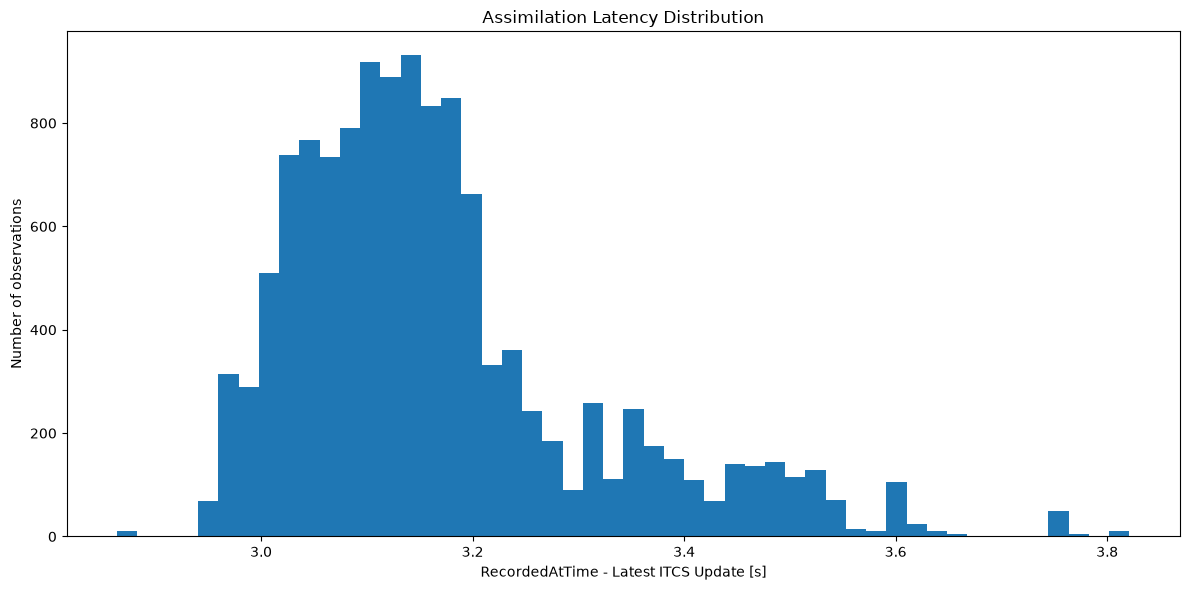

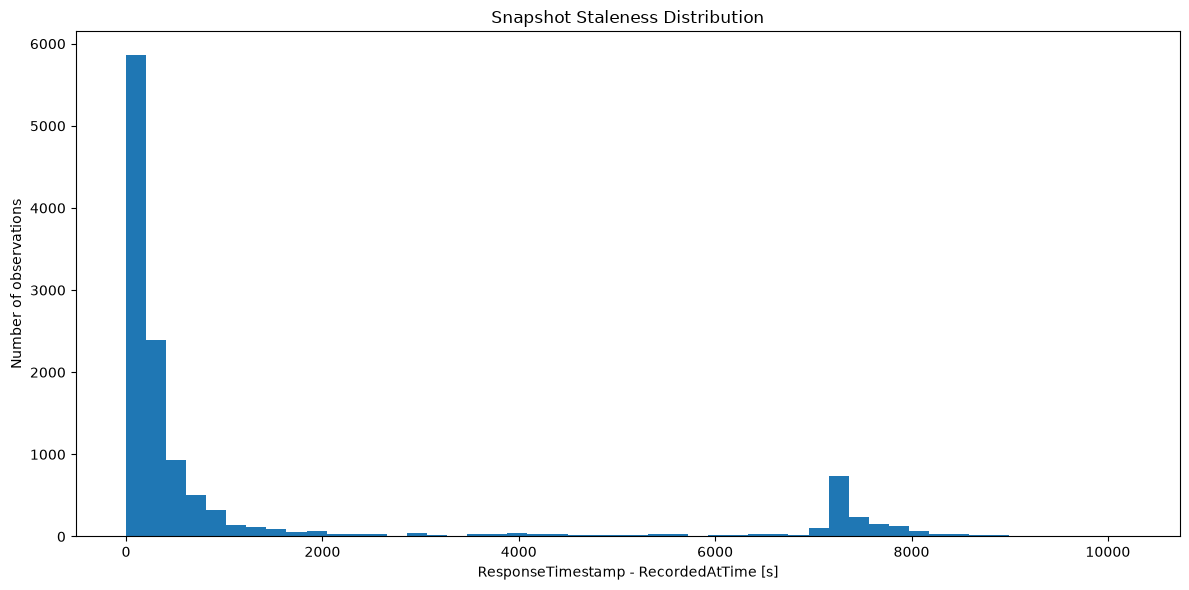

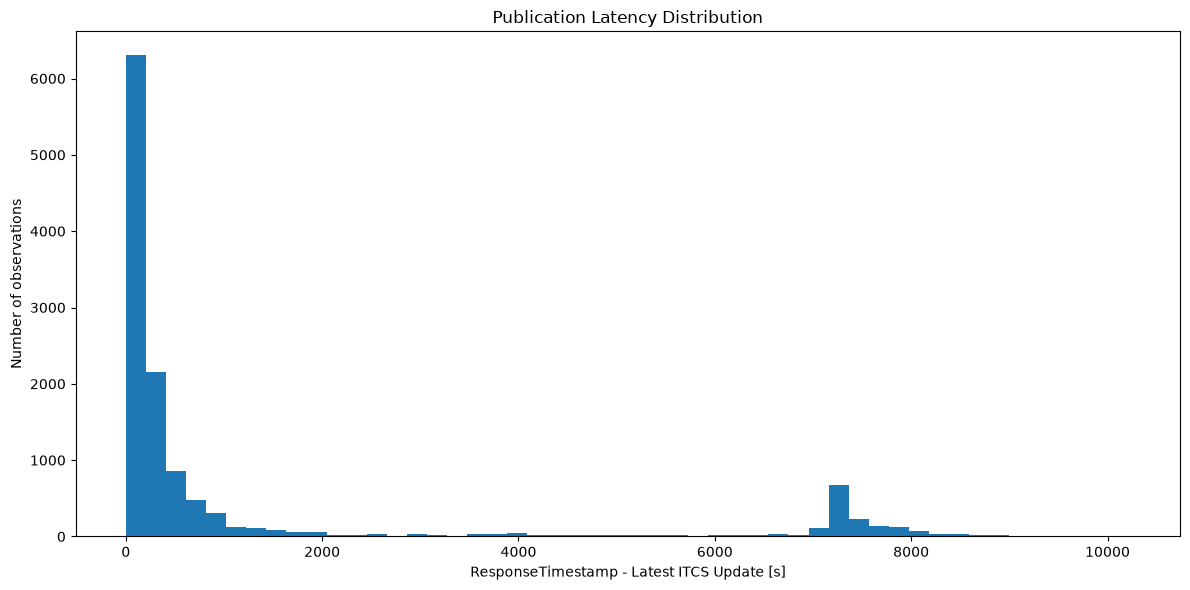

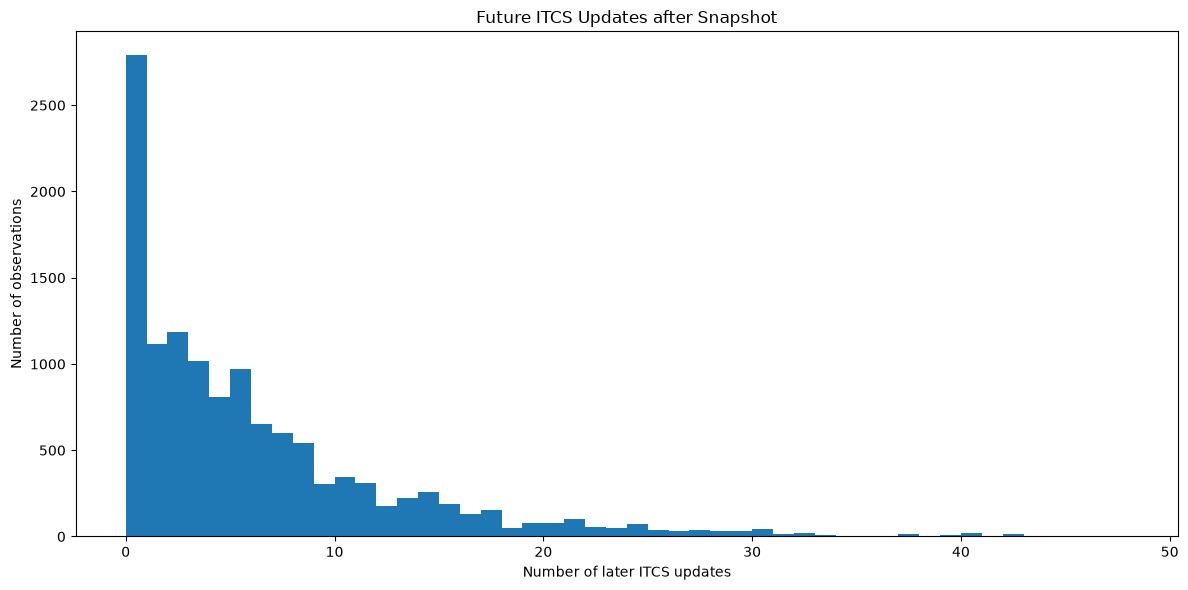

In [11]:
from __future__ import annotations

from statistics import mean
from typing import List

import matplotlib.pyplot as plt


# --------------------------------------------------
# Inputs
#
# trip_timestamps:
#   dict[str, list[datetime]]
#
# journey_observations:
#   dict[str, list[JourneyObservation]]
# --------------------------------------------------


assimilation_latency_seconds: List[float] = []
snapshot_staleness_seconds: List[float] = []
publication_latency_seconds: List[float] = []
updates_after_snapshot: List[int] = []

matched_observations: int = 0


# --------------------------------------------------
# Improved percentile (linear interpolation)
# --------------------------------------------------

def percentile(values: list[float], p: float) -> float:
    if not values:
        raise ValueError("Cannot calculate percentile of empty list")

    sorted_vals = sorted(values)
    n = len(sorted_vals)

    if n == 1:
        return sorted_vals[0]

    index = (n - 1) * p
    lower = int(index)
    upper = min(lower + 1, n - 1)

    weight = index - lower

    return (
        sorted_vals[lower]
        + (sorted_vals[upper] - sorted_vals[lower]) * weight
    )


# --------------------------------------------------
# Core computation
# --------------------------------------------------

for siri_journey, observations in journey_observations.items():

    matching_itcs_journey: str | None = next(
        (
            itcs_journey
            for itcs_journey in trip_timestamps
            if siri_journey.startswith(itcs_journey)
        ),
        None,
    )

    if matching_itcs_journey is None:
        continue

    itcs_updates = trip_timestamps[matching_itcs_journey]

    for observation in observations:

        matched_observations += 1

        # --------------------------------------------------
        # Assimilation Latency
        # --------------------------------------------------

        latest_itcs_before_recorded = max(
            (
                timestamp
                for timestamp in itcs_updates
                if timestamp <= observation.recorded_at
            ),
            default=None,
        )

        if latest_itcs_before_recorded is not None:
            assimilation_latency_seconds.append(
                (observation.recorded_at - latest_itcs_before_recorded).total_seconds()
            )

        # --------------------------------------------------
        # Snapshot Staleness
        # --------------------------------------------------

        snapshot_staleness_seconds.append(
            (observation.response_timestamp - observation.recorded_at).total_seconds()
        )

        # --------------------------------------------------
        # Publication Latency
        # --------------------------------------------------

        latest_itcs_before_response = max(
            (
                timestamp
                for timestamp in itcs_updates
                if timestamp <= observation.response_timestamp
            ),
            default=None,
        )

        if latest_itcs_before_response is not None:
            publication_latency_seconds.append(
                (observation.response_timestamp - latest_itcs_before_response).total_seconds()
            )

        # --------------------------------------------------
        # Future ITCS updates
        # --------------------------------------------------

        count_after = sum(
            1
            for timestamp in itcs_updates
            if timestamp > observation.response_timestamp
        )

        updates_after_snapshot.append(count_after)


# --------------------------------------------------
# Sorting
# --------------------------------------------------

assimilation_latency_seconds.sort()
snapshot_staleness_seconds.sort()
publication_latency_seconds.sort()


# --------------------------------------------------
# Enhanced summary helper
# --------------------------------------------------

def print_metric_summary(name: str, values: list[float]) -> None:

    if not values:
        return

    print()
    print(name)

    print(f"Mean   : {mean(values):.2f} s")

    print(f"P50    : {percentile(values, 0.50):.2f} s")
    print(f"P60    : {percentile(values, 0.60):.2f} s")
    print(f"P70    : {percentile(values, 0.70):.2f} s")
    print(f"P80    : {percentile(values, 0.80):.2f} s")
    print(f"P90    : {percentile(values, 0.90):.2f} s")
    print(f"P95    : {percentile(values, 0.95):.2f} s")
    print(f"P99    : {percentile(values, 0.99):.2f} s")

    print(f"Max    : {max(values):.2f} s")


# --------------------------------------------------
# Output
# --------------------------------------------------

print("---- Summary ----")
print(f"Matched observations: {matched_observations}")


print_metric_summary(
    "Assimilation Latency",
    assimilation_latency_seconds,
)

print_metric_summary(
    "Snapshot Staleness",
    snapshot_staleness_seconds,
)

print_metric_summary(
    "Publication Latency",
    publication_latency_seconds,
)


if updates_after_snapshot:

    print()
    print("Future ITCS Updates")

    print(f"Mean   : {mean(updates_after_snapshot):.2f}")
    print(f"P50    : {percentile(updates_after_snapshot, 0.50):.2f}")
    print(f"P90    : {percentile(updates_after_snapshot, 0.90):.2f}")
    print(f"Max    : {max(updates_after_snapshot)}")


# --------------------------------------------------
# Plot 1 - Assimilation
# --------------------------------------------------

plt.figure(figsize=(12, 6))
plt.hist(assimilation_latency_seconds, bins=50)
plt.title("Assimilation Latency Distribution")
plt.xlabel("RecordedAtTime - Latest ITCS Update [s]")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Plot 2 - Staleness
# --------------------------------------------------

plt.figure(figsize=(12, 6))
plt.hist(snapshot_staleness_seconds, bins=50)
plt.title("Snapshot Staleness Distribution")
plt.xlabel("ResponseTimestamp - RecordedAtTime [s]")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Plot 3 - Publication
# --------------------------------------------------

plt.figure(figsize=(12, 6))
plt.hist(publication_latency_seconds, bins=50)
plt.title("Publication Latency Distribution")
plt.xlabel("ResponseTimestamp - Latest ITCS Update [s]")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Plot 4 - Future updates
# --------------------------------------------------

plt.figure(figsize=(12, 6))
plt.hist(
    updates_after_snapshot,
    bins=range(0, max(updates_after_snapshot) + 2),
)
plt.title("Future ITCS Updates after Snapshot")
plt.xlabel("Number of later ITCS updates")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()

In [15]:
from __future__ import annotations

from pathlib import Path
from datetime import datetime
from statistics import mean, stdev
import matplotlib.pyplot as plt


# --------------------------------------------------
# Path helper (IMPORTANT for Markdown/GitHub/Jupyter)
# --------------------------------------------------

def to_md_path(path: str) -> str:
    """Convert OS path to POSIX path for Markdown rendering."""
    return Path(path).as_posix()


# --------------------------------------------------
# Percentile (linear interpolation)
# --------------------------------------------------

def percentile(values: list[float], p: float) -> float:
    if not values:
        return 0.0

    sorted_vals = sorted(values)
    n = len(sorted_vals)

    if n == 1:
        return sorted_vals[0]

    index = (n - 1) * p
    lower = int(index)
    upper = min(lower + 1, n - 1)

    weight = index - lower

    return (
        sorted_vals[lower]
        + (sorted_vals[upper] - sorted_vals[lower]) * weight
    )


def safe_stats(values: list[float]) -> dict[str, float]:
    if not values:
        return {
            "mean": 0.0,
            "stddev": 0.0,
            "max": 0.0,
            "p50": 0.0,
            "p60": 0.0,
            "p70": 0.0,
            "p80": 0.0,
            "p90": 0.0,
            "p95": 0.0,
            "p99": 0.0,
        }

    return {
        "mean": mean(values),
        "stddev": stdev(values) if len(values) > 1 else 0.0,
        "max": max(values),

        "p50": percentile(values, 0.50),
        "p60": percentile(values, 0.60),
        "p70": percentile(values, 0.70),
        "p80": percentile(values, 0.80),
        "p90": percentile(values, 0.90),
        "p95": percentile(values, 0.95),
        "p99": percentile(values, 0.99),
    }


# --------------------------------------------------
# Plot helper
# --------------------------------------------------

def save_histogram(data, title, filename, xlabel) -> str:
    output_dir = Path("results")
    output_dir.mkdir(exist_ok=True)

    path = output_dir / filename

    plt.figure(figsize=(10, 5))
    plt.hist(data, bins=50)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()

    return str(path)


# --------------------------------------------------
# Plot generation
# --------------------------------------------------

assimilation_plot = save_histogram(
    assimilation_latency_seconds,
    "Assimilation Latency Distribution",
    "assimilation_latency.png",
    "Seconds",
)

staleness_plot = save_histogram(
    snapshot_staleness_seconds,
    "Snapshot Staleness Distribution",
    "snapshot_staleness.png",
    "Seconds",
)

publication_plot = save_histogram(
    publication_latency_seconds,
    "Publication Latency Distribution",
    "publication_latency.png",
    "Seconds",
)

updates_plot = save_histogram(
    updates_after_snapshot,
    "ITCS Update Count after Snapshot",
    "updates_after_snapshot.png",
    "Number of updates",
)


# --------------------------------------------------
# Metadata
# --------------------------------------------------

start_time = analysis_start.isoformat()
end_time = analysis_end.isoformat()

num_snapshots = num_siri_files
num_observations = sum(len(v) for v in journey_observations.values())

timestamp = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


# --------------------------------------------------
# Statistics
# --------------------------------------------------

assimilation_stats = safe_stats(assimilation_latency_seconds)
staleness_stats = safe_stats(snapshot_staleness_seconds)
publication_stats = safe_stats(publication_latency_seconds)

updates_mean = mean(updates_after_snapshot) if updates_after_snapshot else 0.0
updates_max = max(updates_after_snapshot) if updates_after_snapshot else 0


# --------------------------------------------------
# Markdown builder
# --------------------------------------------------

lines: list[str] = []

lines.append("# SIRI / ITCS Temporal Analysis Report")
lines.append("")
lines.append(f"Generated: {timestamp}")
lines.append("")


# --------------------------------------------------
# Scope
# --------------------------------------------------

lines.append("## 1. Study Design and Data Scope")
lines.append(
    "This analysis investigates temporal coupling between ITCS event streams and SIRI-ET snapshots."
)
lines.append("")
lines.append(f"Observation window: {start_time} → {end_time}")
lines.append(f"Number of SIRI snapshots: {num_snapshots}")
lines.append(f"Number of filtered journey observations: {num_observations}")
lines.append("")


# --------------------------------------------------
# Section helper
# --------------------------------------------------

def add_section(title: str, description: str, stats: dict[str, float], plot: str):
    lines.append(f"## {title}")
    lines.append(description)
    lines.append("")
    lines.append("Statistical summary:")

    lines.append(f"- Mean: {stats['mean']:.3f}")
    lines.append(f"- StdDev: {stats['stddev']:.3f}")
    lines.append(f"- Max: {stats['max']:.3f}")

    lines.append(f"- P50: {stats['p50']:.3f}")
    lines.append(f"- P60: {stats['p60']:.3f}")
    lines.append(f"- P70: {stats['p70']:.3f}")
    lines.append(f"- P80: {stats['p80']:.3f}")
    lines.append(f"- P90: {stats['p90']:.3f}")
    lines.append(f"- P95: {stats['p95']:.3f}")
    lines.append(f"- P99: {stats['p99']:.3f}")

    lines.append("")
    lines.append("Distribution:")
    lines.append(f"![{title}]({to_md_path(plot)})")
    lines.append("")


# --------------------------------------------------
# Metrics
# --------------------------------------------------

add_section(
    "2. Assimilation Latency",
    "Time between last ITCS update and ET RecordedAtTime.",
    assimilation_stats,
    assimilation_plot,
)

add_section(
    "3. Snapshot Staleness",
    "Time gap between ET creation and publication.",
    staleness_stats,
    staleness_plot,
)

add_section(
    "4. Publication Latency",
    "End-to-end delay from ITCS update to SIRI availability.",
    publication_stats,
    publication_plot,
)


# --------------------------------------------------
# ITCS dynamics
# --------------------------------------------------

lines.append("## 5. Post-snapshot ITCS Update Activity")
lines.append("")
lines.append(f"- Mean: {updates_mean:.3f}")
lines.append(f"- Max: {updates_max}")
lines.append("")
lines.append("Distribution:")
lines.append(f"![ITCS Updates]({to_md_path(updates_plot)})")
lines.append("")


# --------------------------------------------------
# Interpretation
# --------------------------------------------------

lines.append("## 6. Interpretation")
lines.append(
    "The decomposition separates ingestion latency, processing delay, and dissemination delay, "
    "enabling structured evaluation of real-time transport information systems."
)
lines.append("")


# --------------------------------------------------
# Appendix
# --------------------------------------------------

lines.append("## Appendix: Full Quantile Summary")
lines.append("")

for name, stats in [
    ("Assimilation Latency", assimilation_stats),
    ("Snapshot Staleness", staleness_stats),
    ("Publication Latency", publication_stats),
]:
    lines.append(f"### {name}")
    lines.append(f"- Mean: {stats['mean']:.3f}")
    lines.append(f"- StdDev: {stats['stddev']:.3f}")
    lines.append(f"- P50: {stats['p50']:.3f}")
    lines.append(f"- P60: {stats['p60']:.3f}")
    lines.append(f"- P70: {stats['p70']:.3f}")
    lines.append(f"- P80: {stats['p80']:.3f}")
    lines.append(f"- P90: {stats['p90']:.3f}")
    lines.append(f"- P95: {stats['p95']:.3f}")
    lines.append(f"- P99: {stats['p99']:.3f}")
    lines.append(f"- Max: {stats['max']:.3f}")
    lines.append("")


# --------------------------------------------------
# Write file
# --------------------------------------------------

output_path = Path("RESULTS.md")
output_path.write_text("\n".join(lines), encoding="utf-8")

print("Scientific README generated successfully.")

Scientific README generated successfully.


C:\Users\sebas\AppData\Local\Temp\ipykernel_31988\923223281.py:139: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")
